# Entraînement ALDD sur plusieurs coupes JHTDB

Ce notebook remplace le chargement du sillage de cylindre par le fichier HDF5 contenant plusieurs coupes JHTDB.

Format attendu :

$$
U \in \mathbb{R}^{S \times T \times H \times W}
$$

avec :

- `S` : nombre de coupes fixes en `z` ;
- `T` : nombre de pas de temps ;
- `H, W` : dimensions d'une coupe 2D.

La décomposition crée uniquement deux tableaux :

$$
u_t \quad \text{et}\quad u_{t+1}
$$

sans métadonnées supplémentaires.

## 1. Imports et chemins

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Le notebook peut être exécuté depuis la racine du dépôt ou depuis src/.
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
    SRC_DIR = PROJECT_ROOT / "src"
else:
    SRC_DIR = CURRENT_DIR
    PROJECT_ROOT = SRC_DIR.parent

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import cluster
from pipeline import initialize_model, save_checkpoint, setup_grids
import data_loader

print("Project root :", PROJECT_ROOT)
print("Source dir   :", SRC_DIR)
print("PyTorch      :", torch.__version__)

Project root : /users/m24046/m24046mrcr/ALDD
Source dir   : /users/m24046/m24046mrcr/ALDD/src
PyTorch      : 2.2.0a0+81ea7a4


## 2. Configuration

In [2]:
# Fichier créé lors de l'extraction JHTDB
H5_PATH = PROJECT_ROOT / "JHTDB/data/jhtdb_test/small_planes.h5"

# Intervalle temporel utilisé pour l'entraînement.
# Les indices sont des positions dans le fichier HDF5, pas nécessairement
# les valeurs physiques stockées dans time_indices.
TRAIN_START = 0
TRAIN_STOP = 300       # borne exclue ; mettre None pour utiliser tous les temps

MODEL_TYPE = "fno"     # "fno" ou "deeponet"

N = 16                 # taille d'un sous-domaine N x N
OVERLAP = 1
BATCH_SIZE = 512
EPOCHS = 30
LEARNING_RATE = 5e-4

K_CLUSTER = 5

# Pour N=16, le spectre radial contient environ 13 bins, mode zéro inclus.
TOP_P = 13

RANDOM_SEED = 0

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device      :", device)
print("Model       :", MODEL_TYPE.upper())
print("Dataset     :", H5_PATH)

Device      : cuda
Model       : FNO
Dataset     : /users/m24046/m24046mrcr/ALDD/JHTDB/data/jhtdb_test/small_planes.h5


## 3. Chargement des trajectoires JHTDB

In [3]:
def load_jhtdb_planes(filename, start_t=0, stop_t=None):
    """Charge les coupes sous la forme (S, T, H, W)."""
    with h5py.File(filename, "r") as f:
        trajectories = f["u"][:, start_t:stop_t].astype(np.float32)
        z_indices = f["z_indices"][:]
        time_indices = f["time_indices"][start_t:stop_t]

    return trajectories, z_indices, time_indices


trajectories, z_indices, train_time_indices = load_jhtdb_planes(
    H5_PATH,
    start_t=TRAIN_START,
    stop_t=TRAIN_STOP,
)

print("Trajectories shape :", trajectories.shape)
print("z indices          :", z_indices)
print("Premier temps      :", train_time_indices[0])
print("Dernier temps      :", train_time_indices[-1])

Trajectories shape : (3, 100, 64, 64)
z indices          : [ 64 256 512]
Premier temps      : 1
Dernier temps      : 100


## 4. Petite visualisation

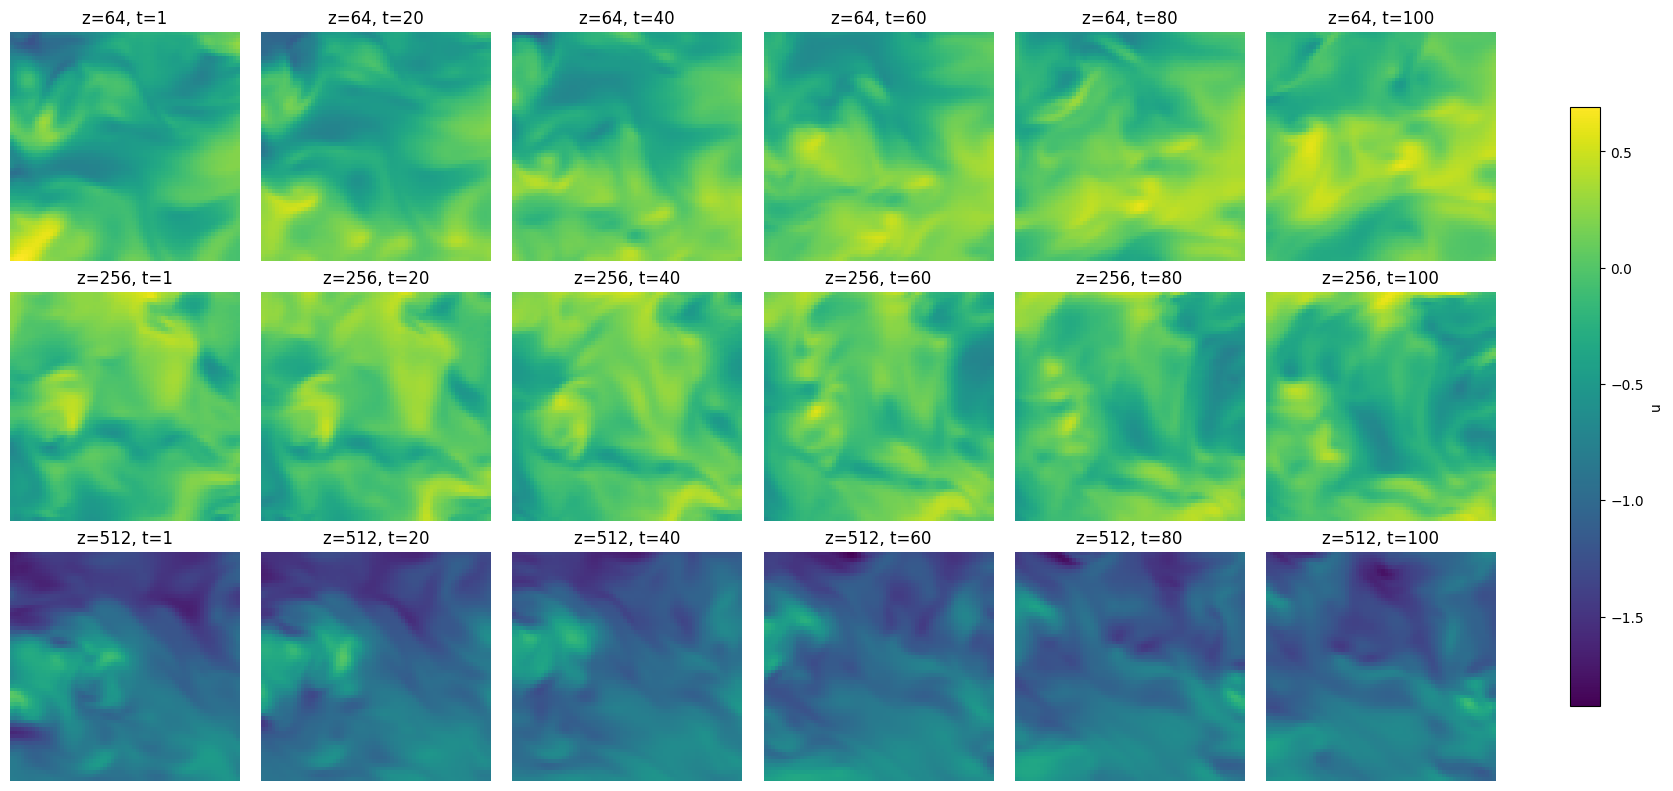

In [4]:
S, T, H, W = trajectories.shape

n_display = min(6, T)
display_indices = np.linspace(0, T - 1, n_display, dtype=int)

fig, axes = plt.subplots(
    S,
    n_display,
    figsize=(2.8 * n_display, 2.6 * S),
    constrained_layout=True,
    squeeze=False,
)

vmin = trajectories.min()
vmax = trajectories.max()

for s in range(S):
    for j, t_idx in enumerate(display_indices):
        ax = axes[s, j]
        im = ax.imshow(
            trajectories[s, t_idx],
            origin="upper",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"z={z_indices[s]}, t={train_time_indices[t_idx]}")
        ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, label="u")
plt.show()

## 5. Décomposition en sous-domaines

Les paires sont créées séparément pour chaque coupe :

$$
U[s,t] \longrightarrow U[s,t+1]
$$


In [5]:
def domain_decomposition_trajectories(
    trajectories,
    block_size=16,
    overlap=1,
):
    """Décompose (S,T,H,W) en deux tableaux de blocs appariés."""
    S, T, H, W = trajectories.shape
    step = block_size - overlap

    subdomains_t = []
    subdomains_t1 = []

    for s in range(S):
        for t in range(T - 1):
            frame_t = trajectories[s, t]
            frame_t1 = trajectories[s, t + 1]

            for i in range(0, H - block_size + 1, step):
                for j in range(0, W - block_size + 1, step):
                    subdomains_t.append(
                        frame_t[i:i + block_size, j:j + block_size]
                    )
                    subdomains_t1.append(
                        frame_t1[i:i + block_size, j:j + block_size]
                    )

    return (
        np.asarray(subdomains_t, dtype=np.float32),
        np.asarray(subdomains_t1, dtype=np.float32),
    )


u_t_all, u_t1_all = domain_decomposition_trajectories(
    trajectories,
    block_size=N,
    overlap=OVERLAP,
)

print("u_t shape   :", u_t_all.shape)
print("u_t+1 shape :", u_t1_all.shape)

u_t shape   : (4752, 16, 16)
u_t+1 shape : (4752, 16, 16)


## 6. Réduction spectrale et clustering

Spectral features : (4752, 13)
Centroids         : (5, 13)
Cluster counts    : [1121 1401  771  849  610]


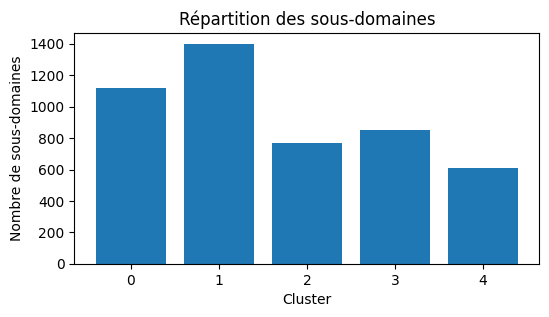

In [6]:
Z_spec = cluster.energy_spectrum_reduction(
    u_t_all,
    top_p=TOP_P,
)

labels, centroids = cluster.wassertein_kmeans(
    Z_spec,
    K_CLUSTER,
)

cluster_counts = np.bincount(labels, minlength=K_CLUSTER)

print("Spectral features :", Z_spec.shape)
print("Centroids         :", centroids.shape)
print("Cluster counts    :", cluster_counts)

plt.figure(figsize=(6, 3))
plt.bar(np.arange(K_CLUSTER), cluster_counts)
plt.xticks(np.arange(K_CLUSTER))
plt.xlabel("Cluster")
plt.ylabel("Nombre de sous-domaines")
plt.title("Répartition des sous-domaines")
plt.show()

## 7. Valeurs de frontière

Le modèle actuel du dépôt traite les valeurs scalaires de la frontière avec une convolution 1D à un canal. On extrait donc uniquement les valeurs de \(u\) sur le périmètre du bloc.

In [7]:
def extract_boundary_tokens(subdomain):
    boundary_values, boundary_xy = data_loader.extract_boundary(subdomain)

    return np.concatenate(
        [
            boundary_xy,                # shape (4*N-4, 2)
            boundary_values[:, None],   # shape (4*N-4, 1)
        ],
        axis=1,
    ).astype(np.float32)

example_boundary = extract_boundary_tokens(u_t_all[0])

print("Sous-domaine :", u_t_all[0].shape)
print("Frontière    :", example_boundary.shape)
print("Attendu      :", (4 * N - 4, 3))

Sous-domaine : (16, 16)
Frontière    : (60, 3)
Attendu      : (60, 3)


## 8. Fonction d'entraînement

In [12]:
def train_models(u_t_all, u_t1_all, labels, grid_data):
    trained_models = []

    for cluster_idx in range(K_CLUSTER):
        cluster_u_t = u_t_all[labels == cluster_idx]
        cluster_u_t1 = u_t1_all[labels == cluster_idx]

        boundary_tokens = np.stack(
            [extract_boundary_tokens(sub) for sub in cluster_u_t]
            )

        boundary_tensor = torch.from_numpy(boundary_tokens)

        if MODEL_TYPE == "fno":
            input_tensor = torch.from_numpy(cluster_u_t).unsqueeze(1)
            target_tensor = torch.from_numpy(cluster_u_t1).unsqueeze(1)
        else:
            input_tensor = torch.from_numpy(
                cluster_u_t.reshape(len(cluster_u_t), -1)
            )
            target_tensor = torch.from_numpy(
                cluster_u_t1.reshape(len(cluster_u_t1), -1)
            )

        dataset = TensorDataset(
            input_tensor,
            target_tensor,
            boundary_tensor,
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            pin_memory=torch.cuda.is_available(),
        )

        model = initialize_model(MODEL_TYPE, N, device)
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE,
        )
        loss_func = nn.MSELoss()

        print(
            f"\nTraining {MODEL_TYPE.upper()} for cluster "
            f"{cluster_idx}: {len(dataset)} samples"
        )

        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0.0

            for batch_u_t, batch_u_t1, batch_boundaries in loader:
                batch_u_t = batch_u_t.to(device, non_blocking=True)
                batch_u_t1 = batch_u_t1.to(device, non_blocking=True)
                batch_boundaries = batch_boundaries.to(
                    device,
                    non_blocking=True,
                )

                optimizer.zero_grad()

                if MODEL_TYPE == "fno":
                    batch_grid = grid_data.expand(
                        len(batch_u_t),
                        -1,
                        -1,
                        -1,
                    )
                    predictions = model(
                        batch_u_t,
                        batch_grid,
                        batch_boundaries,
                    )
                else:
                    predictions = model(
                        batch_u_t,
                        grid_data,
                        batch_boundaries,
                    )

                loss = loss_func(predictions, batch_u_t1)
                loss.backward()
                optimizer.step()

                total_loss += loss.item() * len(batch_u_t)

            mean_loss = total_loss / len(dataset)

            if epoch == 0 or (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch + 1:3d}/{EPOCHS} "
                    f"| loss = {mean_loss:.6e}"
                )

        trained_models.append(model)

    return trained_models

## 9. Entraînement des modèles spécialisés

In [13]:
grid_data = setup_grids(
    MODEL_TYPE,
    N,
    device,
)

trained_models = train_models(
    u_t_all,
    u_t1_all,
    labels,
    grid_data,
)


Training FNO for cluster 0: 1121 samples
Epoch   1/30 | loss = 2.567672e-01
Epoch  10/30 | loss = 3.390968e-02
Epoch  20/30 | loss = 1.925874e-03
Epoch  30/30 | loss = 7.951673e-04

Training FNO for cluster 1: 1401 samples
Epoch   1/30 | loss = 1.108428e+00
Epoch  10/30 | loss = 9.807678e-02
Epoch  20/30 | loss = 1.005136e-02
Epoch  30/30 | loss = 1.427219e-03

Training FNO for cluster 2: 771 samples
Epoch   1/30 | loss = 5.691790e-02
Epoch  10/30 | loss = 3.672431e-02
Epoch  20/30 | loss = 6.391373e-03
Epoch  30/30 | loss = 1.787937e-03

Training FNO for cluster 3: 849 samples
Epoch   1/30 | loss = 6.191122e-02
Epoch  10/30 | loss = 1.490934e-02
Epoch  20/30 | loss = 2.732979e-03
Epoch  30/30 | loss = 1.435424e-03

Training FNO for cluster 4: 610 samples
Epoch   1/30 | loss = 3.599751e-02
Epoch  10/30 | loss = 1.838930e-02
Epoch  20/30 | loss = 2.044133e-03
Epoch  30/30 | loss = 8.790690e-04


In [1]:
from numpy.random.mtrand import permutation

import data_loader
import cluster
import torch
import torch.nn as nn
import numpy as np
from pipeline import initialize_model, save_checkpoint, setup_grids


# Configuration and hyperparameters
MODEL_TYPE = 'fno'  # model: 'fno' or 'deeponet'

DATASET = "jhtdb"  # "cylinder" or "jhtdb"
JHTDB_PATH = "../JHTDB/data/jhtdb_test/small_planes.h5"
TRAIN_Z = [64, 512]  # Hold out the remaining z planes for validation.
TRAIN_START = 0
TRAIN_STOP = None

N = 16     # Subdomain size (NxN)
BATCH_SIZE = 512
EPOCHS = 100
K_CLUSTER = 3
TOP_P = 25 # Dimension reduction for subdomain clustering

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Training loop
def train_models(u_t_all, u_t1_all, labels, grid_data):
    trained_models = []
    channels = u_t_all.shape[-1] if u_t_all.ndim == 4 else 1

    for cluster_idx in range(K_CLUSTER):
        cluster_u_t = u_t_all[labels == cluster_idx]
        cluster_u_t1 = u_t1_all[labels == cluster_idx]
        cluster_boundary_vals = []
        cluster_boundary_xy = []
        for sub in cluster_u_t:
            vals, xy = data_loader.extract_boundary(sub)
            cluster_boundary_vals.append(vals)
            cluster_boundary_xy.append(xy)

        print(f"Training {MODEL_TYPE.upper()} for Cluster {cluster_idx} ({len(cluster_u_t)} samples)")

        # Format Tensors based on model type
        vals_tensor = torch.tensor(np.stack(cluster_boundary_vals), dtype=torch.float32)
        xy_tensor   = torch.tensor(np.stack(cluster_boundary_xy), dtype=torch.float32)
        if vals_tensor.ndim == 2:
            vals_tensor = vals_tensor.unsqueeze(-1)
        boundary_tensor = torch.cat([xy_tensor, vals_tensor], dim=-1).to(device)

        if MODEL_TYPE == 'fno':
            u_t_tensor = torch.tensor(cluster_u_t, dtype=torch.float32)
            u_t1_tensor = torch.tensor(cluster_u_t1, dtype=torch.float32)
            if u_t_tensor.ndim == 3:
                u_t_tensor = u_t_tensor.unsqueeze(-1)
                u_t1_tensor = u_t1_tensor.unsqueeze(-1)
            u_t_tensor = u_t_tensor.permute(0, 3, 1, 2).to(device)
            u_t1_tensor = u_t1_tensor.permute(0, 3, 1, 2).to(device)
        else:
            u_t_tensor = torch.tensor([sub.flatten() for sub in cluster_u_t], dtype=torch.float32).to(device)
            u_t1_tensor = torch.tensor([sub.flatten() for sub in cluster_u_t1], dtype=torch.float32).to(device)

        model = initialize_model(MODEL_TYPE, N, device, channels=channels)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        loss_func = nn.MSELoss()

        for epoch in range(EPOCHS):
            model.train()
            epoch_loss = 0
            permutation = torch.randperm(len(u_t_tensor))
            for i in range(0, len(u_t_tensor), BATCH_SIZE):
                idx = permutation[i:i+BATCH_SIZE]
                batch_u_t = u_t_tensor[idx]
                batch_u_t1 = u_t1_tensor[idx]
                batch_boundaries = boundary_tensor[idx]

                optimizer.zero_grad()

                if MODEL_TYPE == 'fno':
                    batch_grid = grid_data.expand(len(batch_u_t), -1, -1, -1)
                    predictions = model.forward(batch_u_t, batch_grid, batch_boundaries)
                else:
                    predictions = model.forward(batch_u_t, grid_data, batch_boundaries)

                loss = loss_func(predictions, batch_u_t1)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / (len(u_t_tensor) / BATCH_SIZE):.6f}")

        trained_models.append(model)

    return trained_models


if __name__ == "__main__":
    print(f"Device: {device}")
    print(f"Model Type: {MODEL_TYPE.upper()}")

    # Setup grids
    grid_data = setup_grids(MODEL_TYPE, N, device)

    # Load data and cluster
    if DATASET == "jhtdb":
        trajectories, z_indices, _ = data_loader.load_jhtdb_data(
            JHTDB_PATH,
            z_indices=TRAIN_Z,
            start_t=TRAIN_START,
            stop_t=TRAIN_STOP,
            component=("u", "v", "w")
        )
        print(f"Training z planes: {z_indices}")
        u_t_all, u_t1_all = data_loader.domain_decomposition_trajectories(
            trajectories, N
        )
    else:
        time_series = data_loader.load_data(num_timesteps=100, start_t=0)
        u_t_all, u_t1_all = data_loader.domain_decomposition(time_series, N)

    Z_spec = cluster.energy_spectrum_reduction(u_t_all, top_p=TOP_P)
    labels, centroids = cluster.wassertein_kmeans(Z_spec, K_CLUSTER)

    # Training
    trained_models = train_models(u_t_all, u_t1_all, labels, grid_data)

    checkpoint_path = save_checkpoint(
        trained_models=trained_models,
        centroids=centroids,
        model_type=MODEL_TYPE,
        n=N,
        epochs=EPOCHS,
        k_cluster=K_CLUSTER,
        top_p=TOP_P,
    )
    print(f"Saved checkpoint: {checkpoint_path}")


Device: cuda
Model Type: FNO
Training z planes: [ 64 512]
Training FNO for Cluster 0 (2459 samples)
Epoch 10/100, Loss: 0.071450
Epoch 20/100, Loss: 0.015459
Epoch 30/100, Loss: 0.003321
Epoch 40/100, Loss: 0.001208
Epoch 50/100, Loss: 0.000659
Epoch 60/100, Loss: 0.000446
Epoch 70/100, Loss: 0.000349
Epoch 80/100, Loss: 0.000301
Epoch 90/100, Loss: 0.000389
Epoch 100/100, Loss: 0.000231
Training FNO for Cluster 1 (2020 samples)
Epoch 10/100, Loss: 0.087811
Epoch 20/100, Loss: 0.031443
Epoch 30/100, Loss: 0.006653
Epoch 40/100, Loss: 0.001927
Epoch 50/100, Loss: 0.000842
Epoch 60/100, Loss: 0.000726
Epoch 70/100, Loss: 0.000493
Epoch 80/100, Loss: 0.000482
Epoch 90/100, Loss: 0.000422
Epoch 100/100, Loss: 0.000497
Training FNO for Cluster 2 (471 samples)
Epoch 10/100, Loss: 0.265051
Epoch 20/100, Loss: 0.175759
Epoch 30/100, Loss: 0.141670
Epoch 40/100, Loss: 0.060041
Epoch 50/100, Loss: 0.044077
Epoch 60/100, Loss: 0.030195
Epoch 70/100, Loss: 0.023608
Epoch 80/100, Loss: 0.019068
Epo

Device: cuda
Checkpoint: ./models/fno_e100_k3_n16_top25.pt
Model Type: FNO
Epochs: 100
Number of clusters: 3
Subdomain size: 16
Spectral bins: 25
Validation up to T+10
Validating z=256
Step: 1/9 | R² Score: -1.6443
Step: 2/9 | R² Score: -5.1555
Step: 3/9 | R² Score: -6.4853
Step: 4/9 | R² Score: -7.2928
Step: 5/9 | R² Score: -8.1209
Step: 6/9 | R² Score: -8.9907
Step: 7/9 | R² Score: -9.9118
Step: 8/9 | R² Score: -10.8850
Step: 9/9 | R² Score: -11.9222


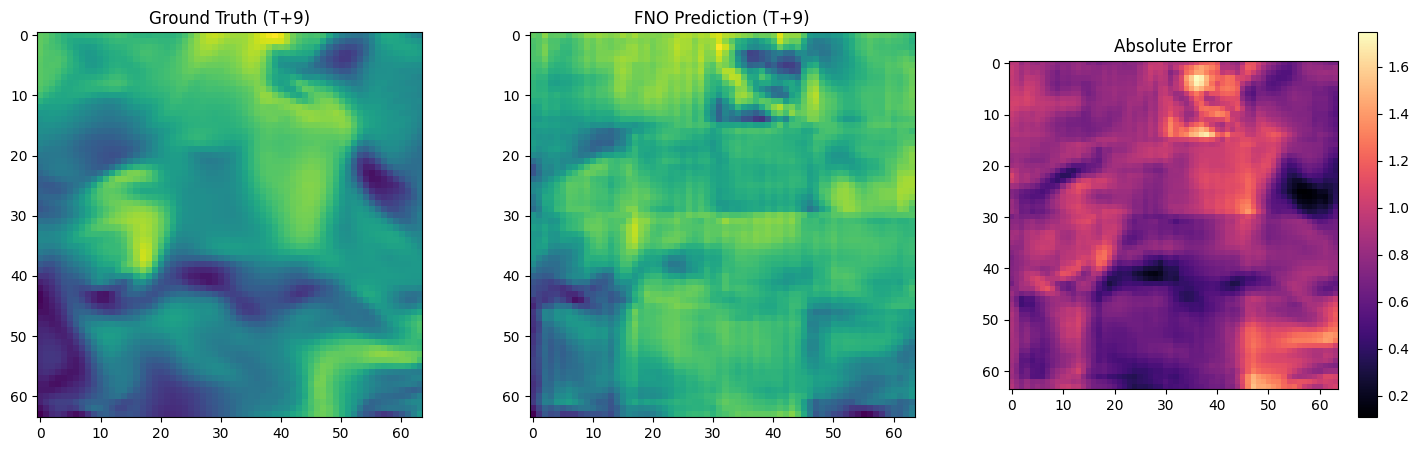

In [6]:
import torch

from pipeline import (
    load_checkpoint,
    setup_grids,
    validate_autoregressive,
)


VAL_TIMESTEPS = 10
DATASET = "jhtdb"
JHTDB_PATH = "../JHTDB/data/jhtdb_test/small_planes.h5"
VAL_Z = [256]

CHECKPOINT_PATH = "./models/fno_e100_k3_n16_top25.pt"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


checkpoint, trained_models = load_checkpoint(
    CHECKPOINT_PATH,
    device,
)

print(f"Device: {device}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Model Type: {checkpoint['model_type'].upper()}")
print(f"Epochs: {checkpoint['epochs']}")
print(f"Number of clusters: {checkpoint['k_cluster']}")
print(f"Subdomain size: {checkpoint['n']}")
print(f"Spectral bins: {checkpoint['top_p']}")


grid_data = setup_grids(
    checkpoint["model_type"],
    checkpoint["n"],
    device,
)


validate_autoregressive(
    trained_models=trained_models,
    centroids=checkpoint["centroids"],
    grid_data=grid_data,
    model_type=checkpoint["model_type"],
    n=checkpoint["n"],
    top_p=checkpoint["top_p"],
    val_timesteps=VAL_TIMESTEPS,
    device=device,
    dataset=DATASET,
    data_path=JHTDB_PATH,
    val_z=VAL_Z,
)
